# Tint-sensitivity figure package

## tl;dr

This is the **PARTIAL** frozen analysis package with **29/36** included models. Corrected thermal spectra are available for **0** models. Partial figures are diagnostic only; missing panels and non-converged curves are intentionally visible.

## Context & Methods

The source cohort is fixed by `frozen_manifest.json`, including SHA-256 hashes. Tint is encoded by color (25/50/100 K), while dashed lines indicate climate non-convergence.

### Key Assumptions

The 1 mbar abundance is a standardized transmission-photosphere proxy, not a contribution-function-derived photosphere. The 20–50 ppm JWST band is illustrative rather than instrument/mode/target-specific.

## Data

### 1. Load the frozen manifest and summary tables

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

package = Path('/home/u11/danielxinhuang/Documents/aurora/analysis/tint_sensitivity_figures/partial_20260721')
manifest = json.loads((package / 'frozen_manifest.json').read_text())
summary = pd.read_csv(package / 'tables/photospheric_abundances_1mbar.csv')
h2o = pd.read_csv(package / 'tables/h2o_sanity_check.csv')
wogan = pd.read_csv(package / 'tables/k2_18b_wogan_direction_check.csv')
{key: manifest[key] for key in ['mode', 'expected_models', 'included_models', 'nonconverged_indices', 'corrected_thermal_indices']}

{'mode': 'partial',
 'expected_models': 36,
 'included_models': 29,
 'nonconverged_indices': [2, 6, 7, 10, 14, 18, 22, 26],
 'corrected_thermal_indices': []}

### 2. Confirm the 36-row writeup table

In [2]:
assert len(summary) == 36
summary[['run_index','case_id','tint_k','cloud_id','metallicity_xsolar','status','climate_converged']].head(12)

,run_index,case_id,tint_k,cloud_id,metallicity_xsolar,status,climate_converged
0,0,k2_18b_observed,25.0,cloud_free,1.0,included,True
1,1,k2_18b_observed,25.0,cloud_free,100.0,included,True
2,2,k2_18b_observed,25.0,fully_cloudy_virga,1.0,included,False
3,3,k2_18b_observed,25.0,fully_cloudy_virga,100.0,included,True
4,4,k2_18b_observed,50.0,cloud_free,1.0,included,True
5,5,k2_18b_observed,50.0,cloud_free,100.0,included,True
6,6,k2_18b_observed,50.0,fully_cloudy_virga,1.0,included,False
7,7,k2_18b_observed,50.0,fully_cloudy_virga,100.0,included,False
8,8,k2_18b_observed,100.0,cloud_free,1.0,included,True
9,9,k2_18b_observed,100.0,cloud_free,100.0,included,True


## Results

### 3. Inspect representative figures

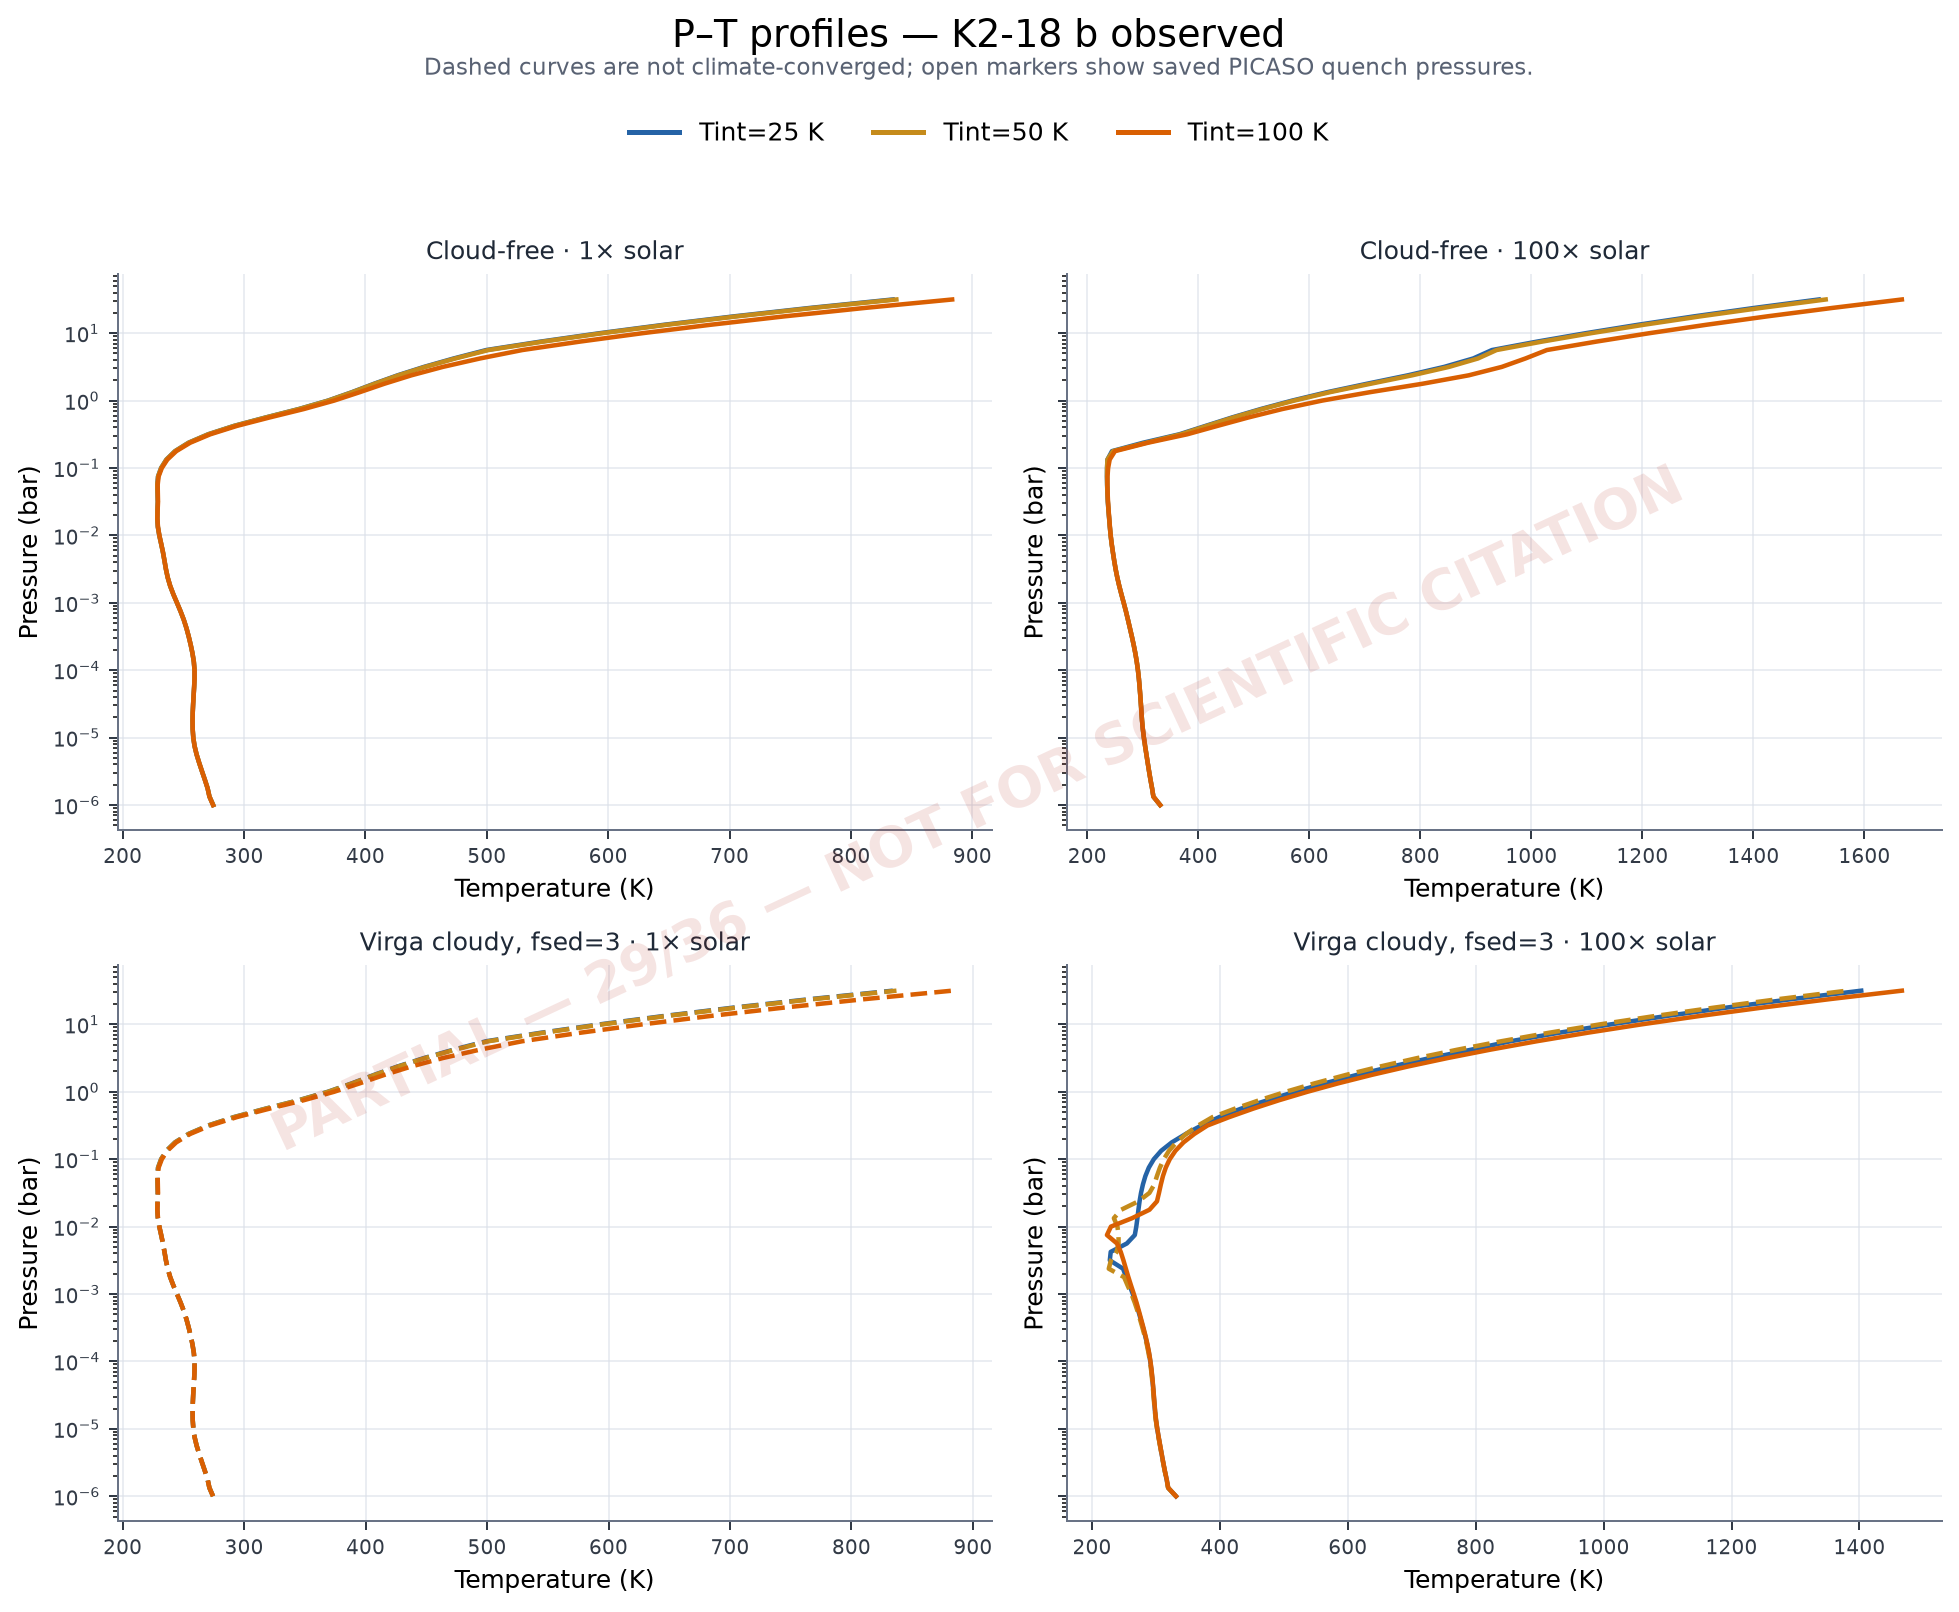

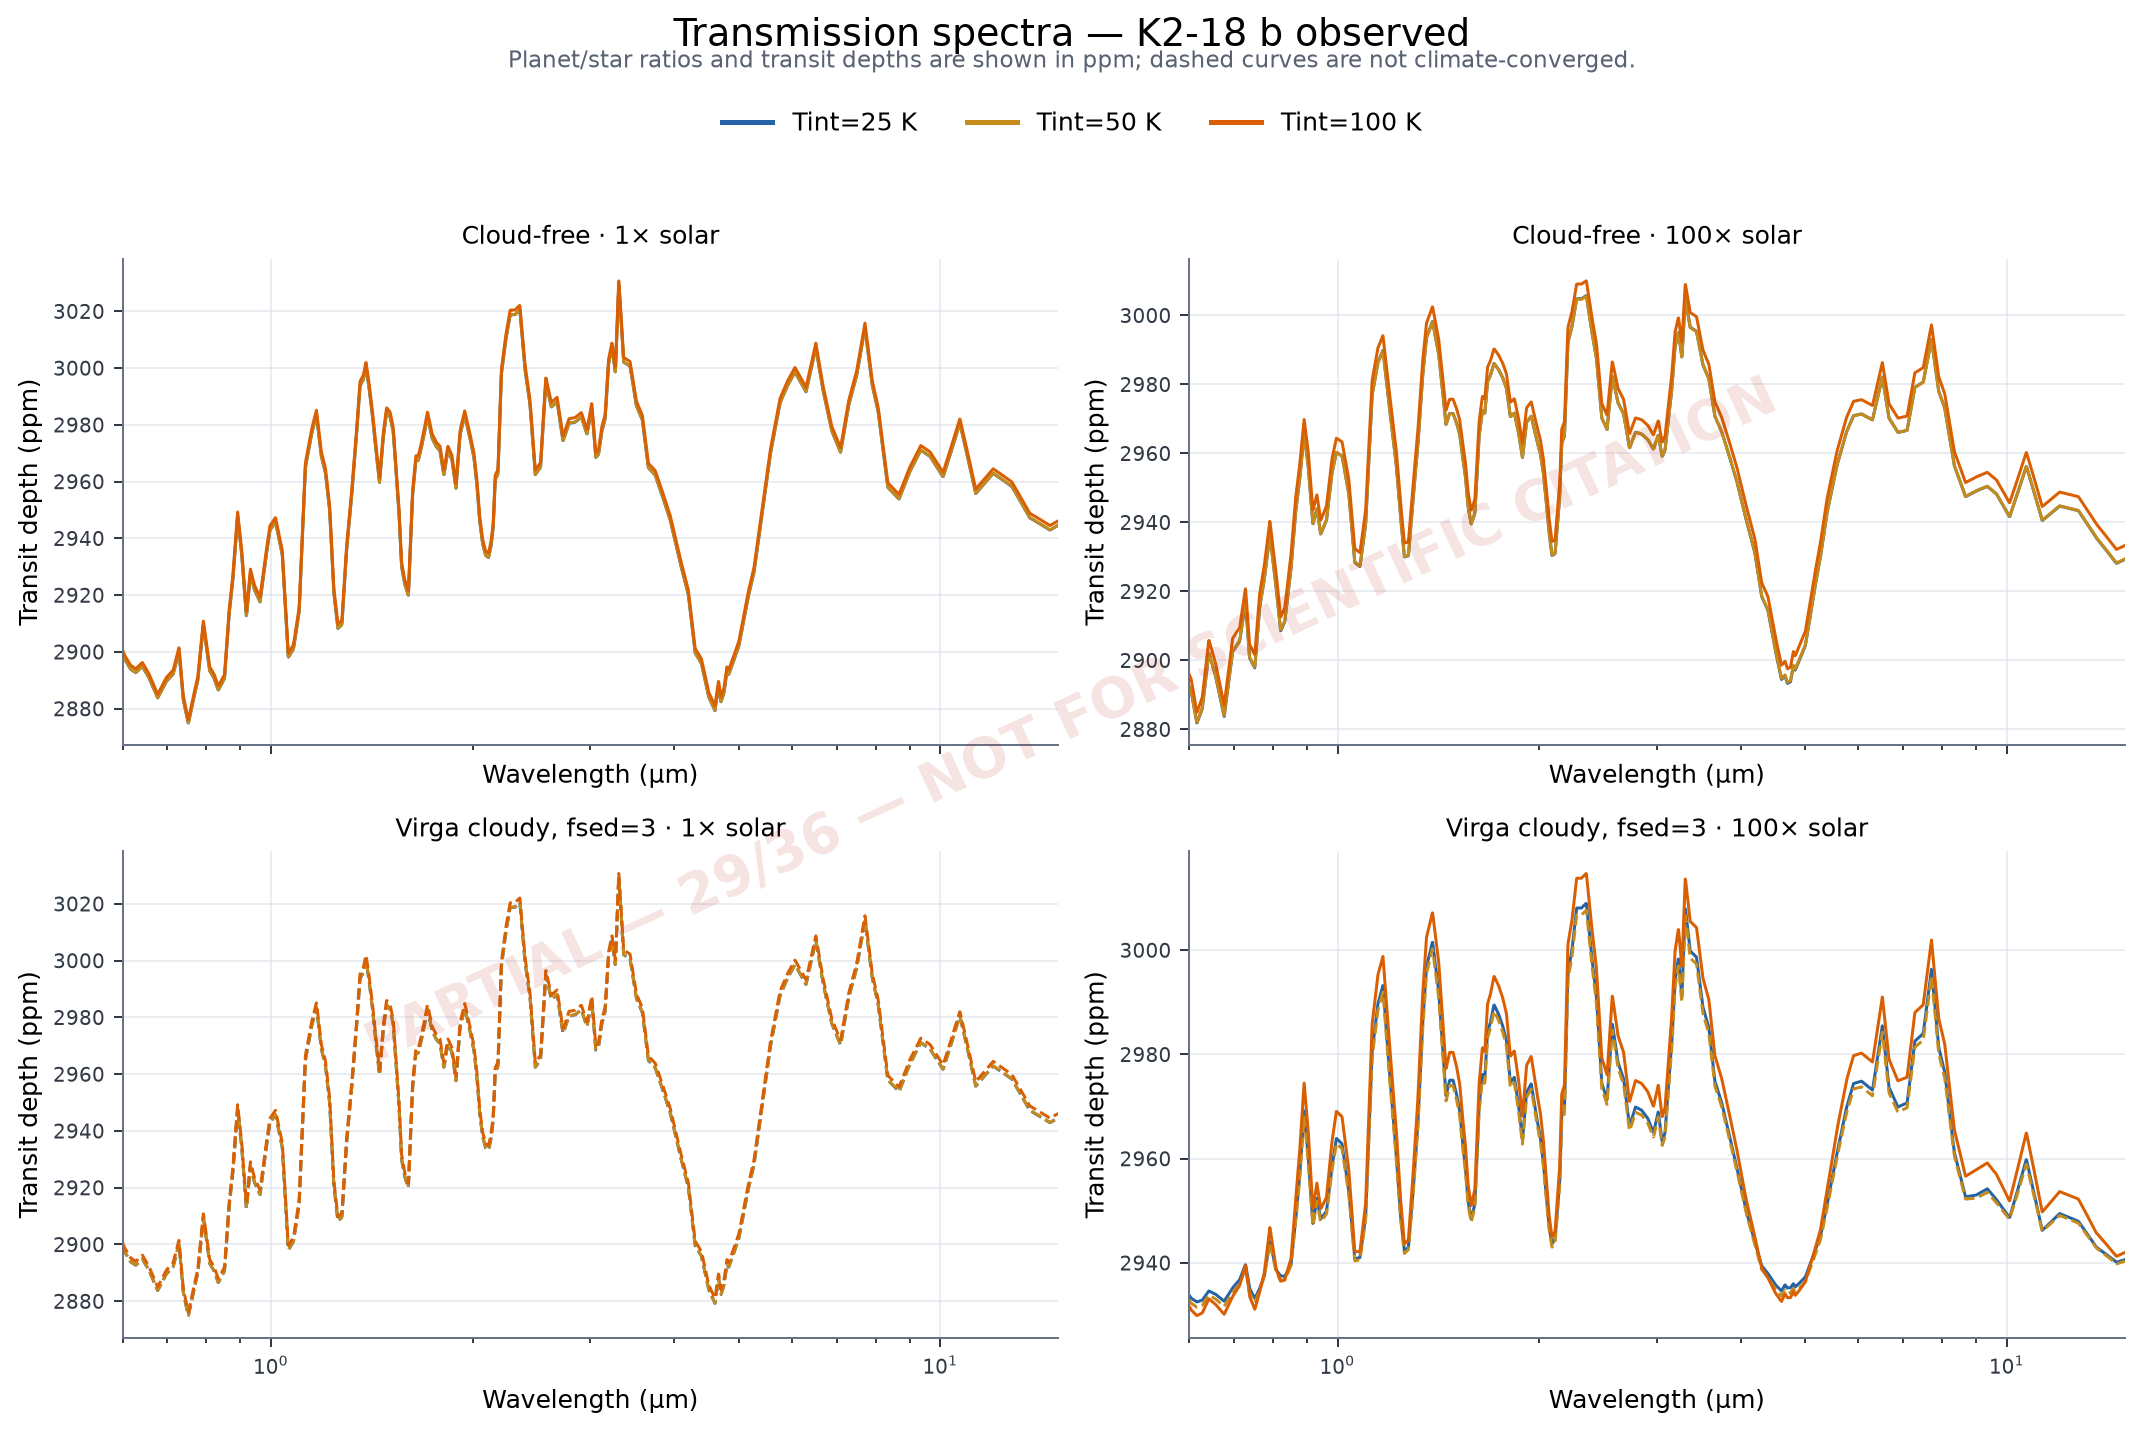

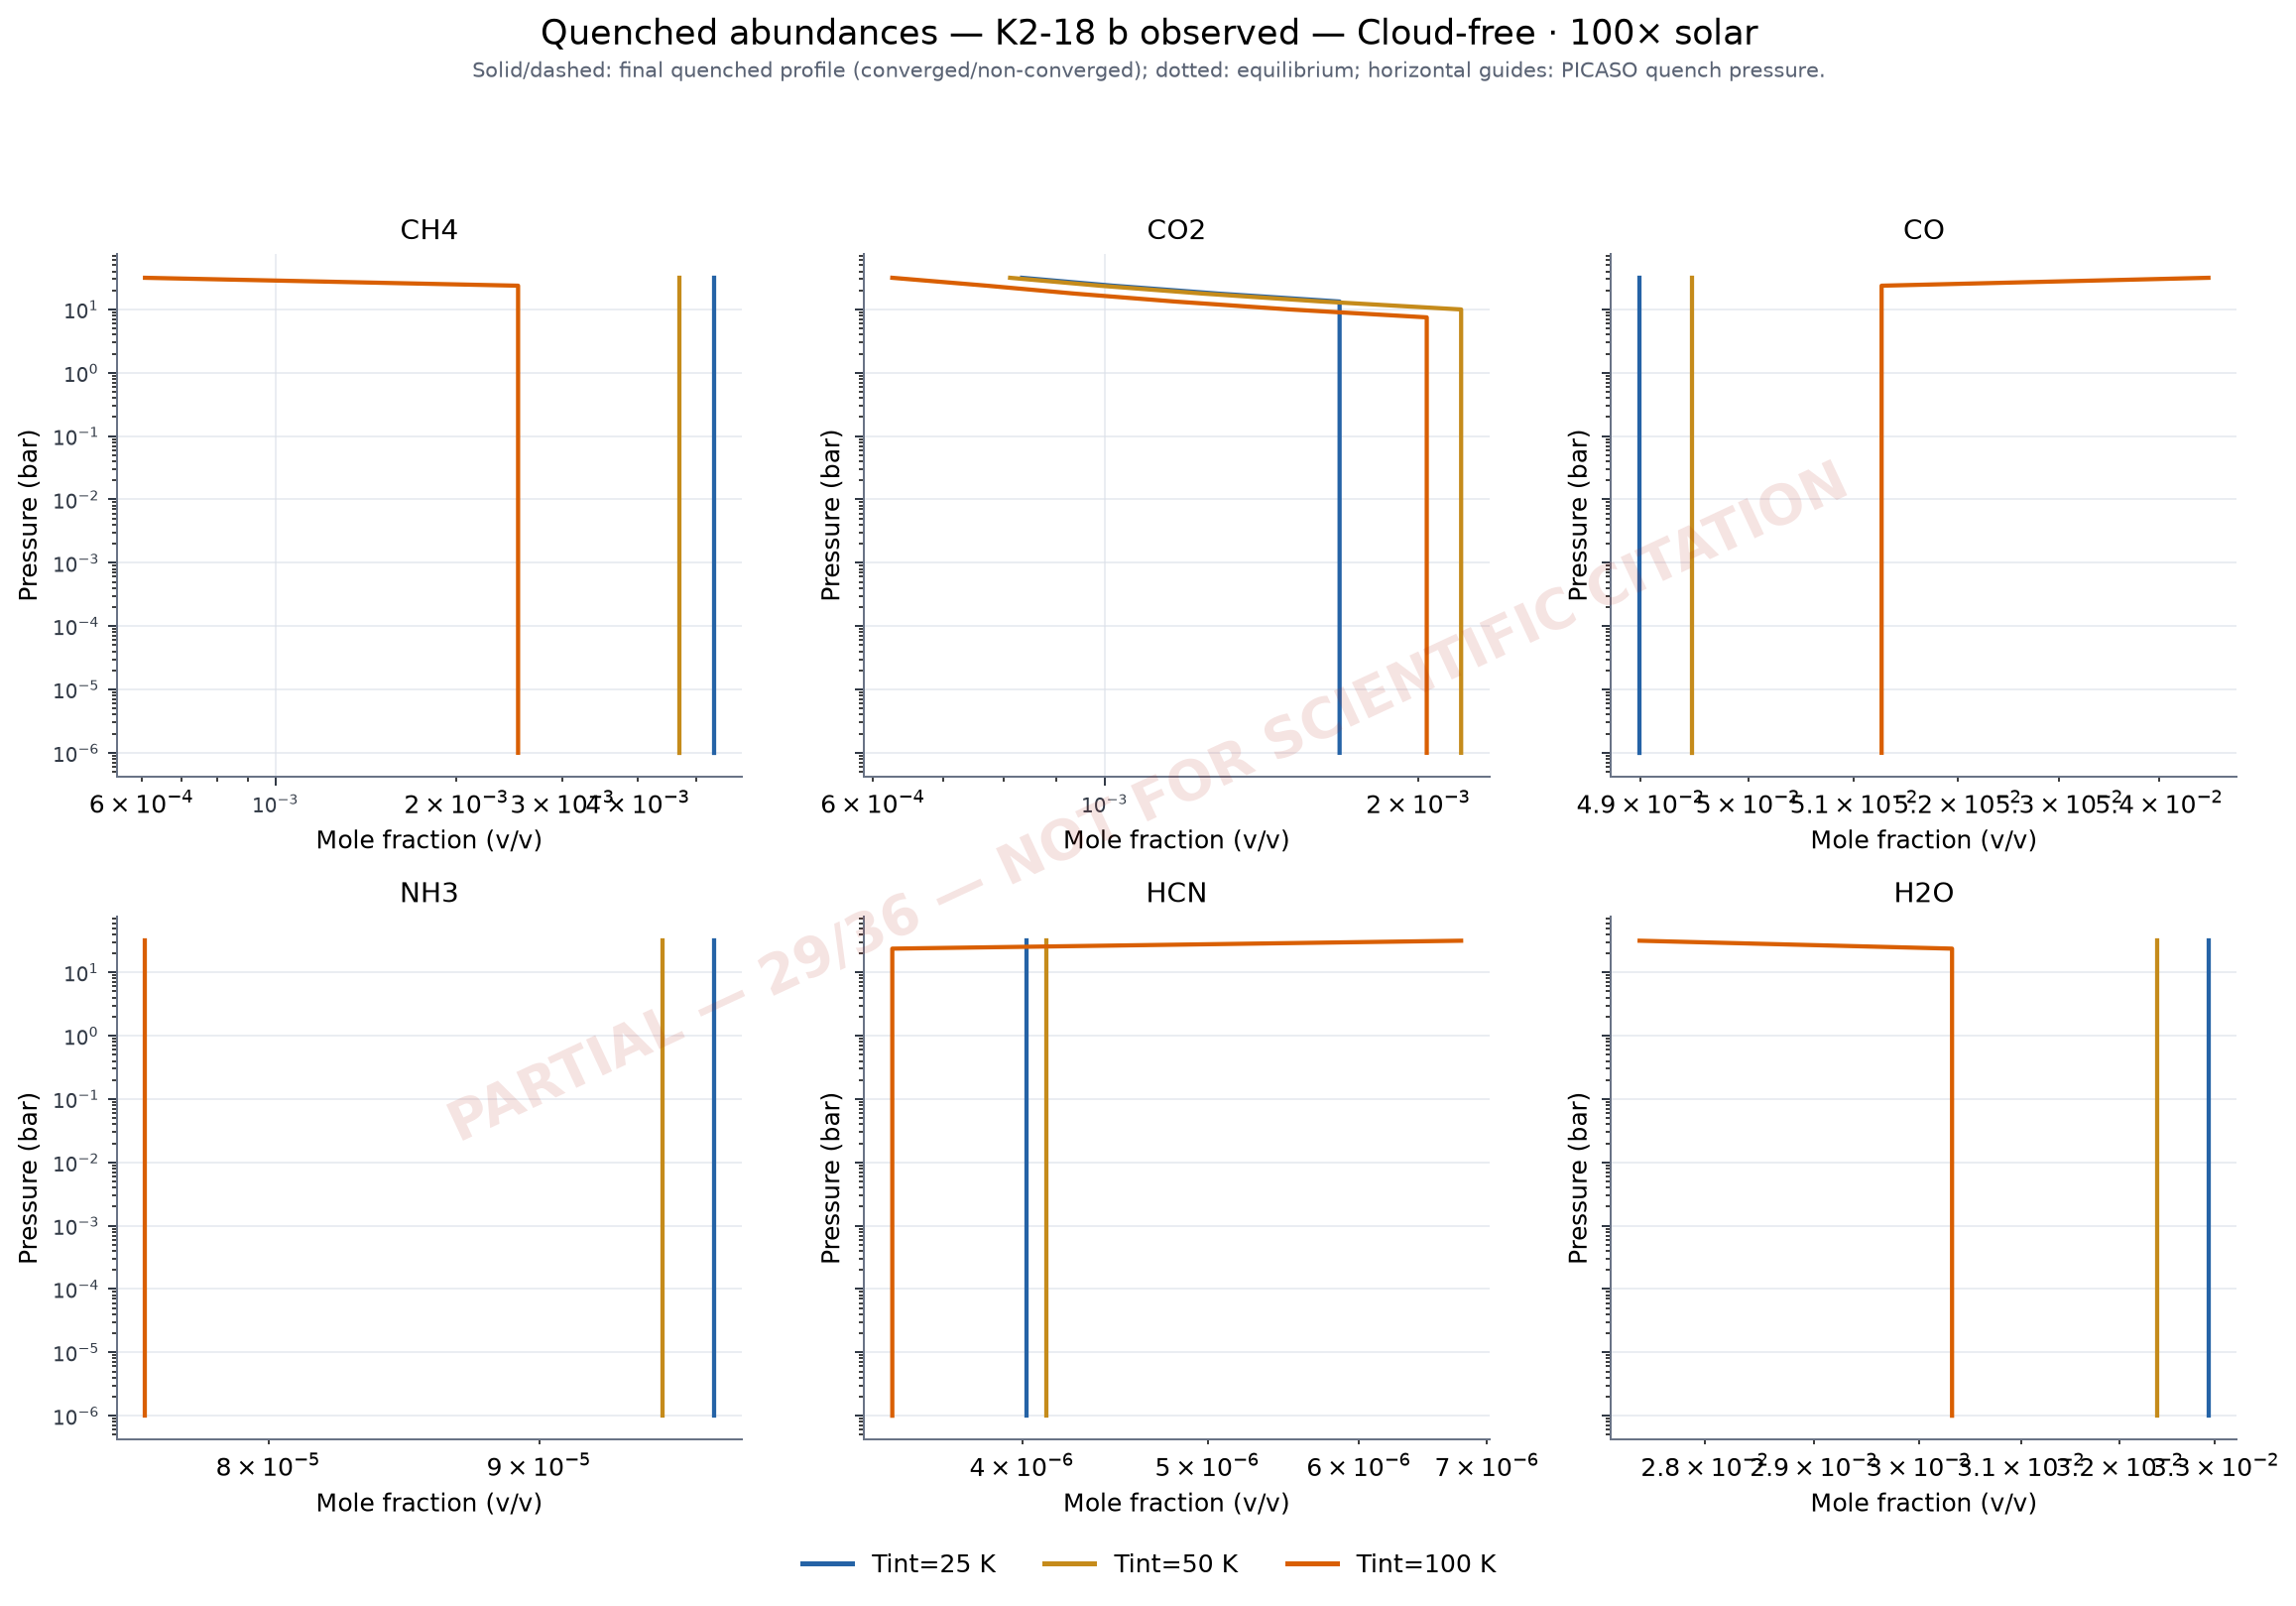

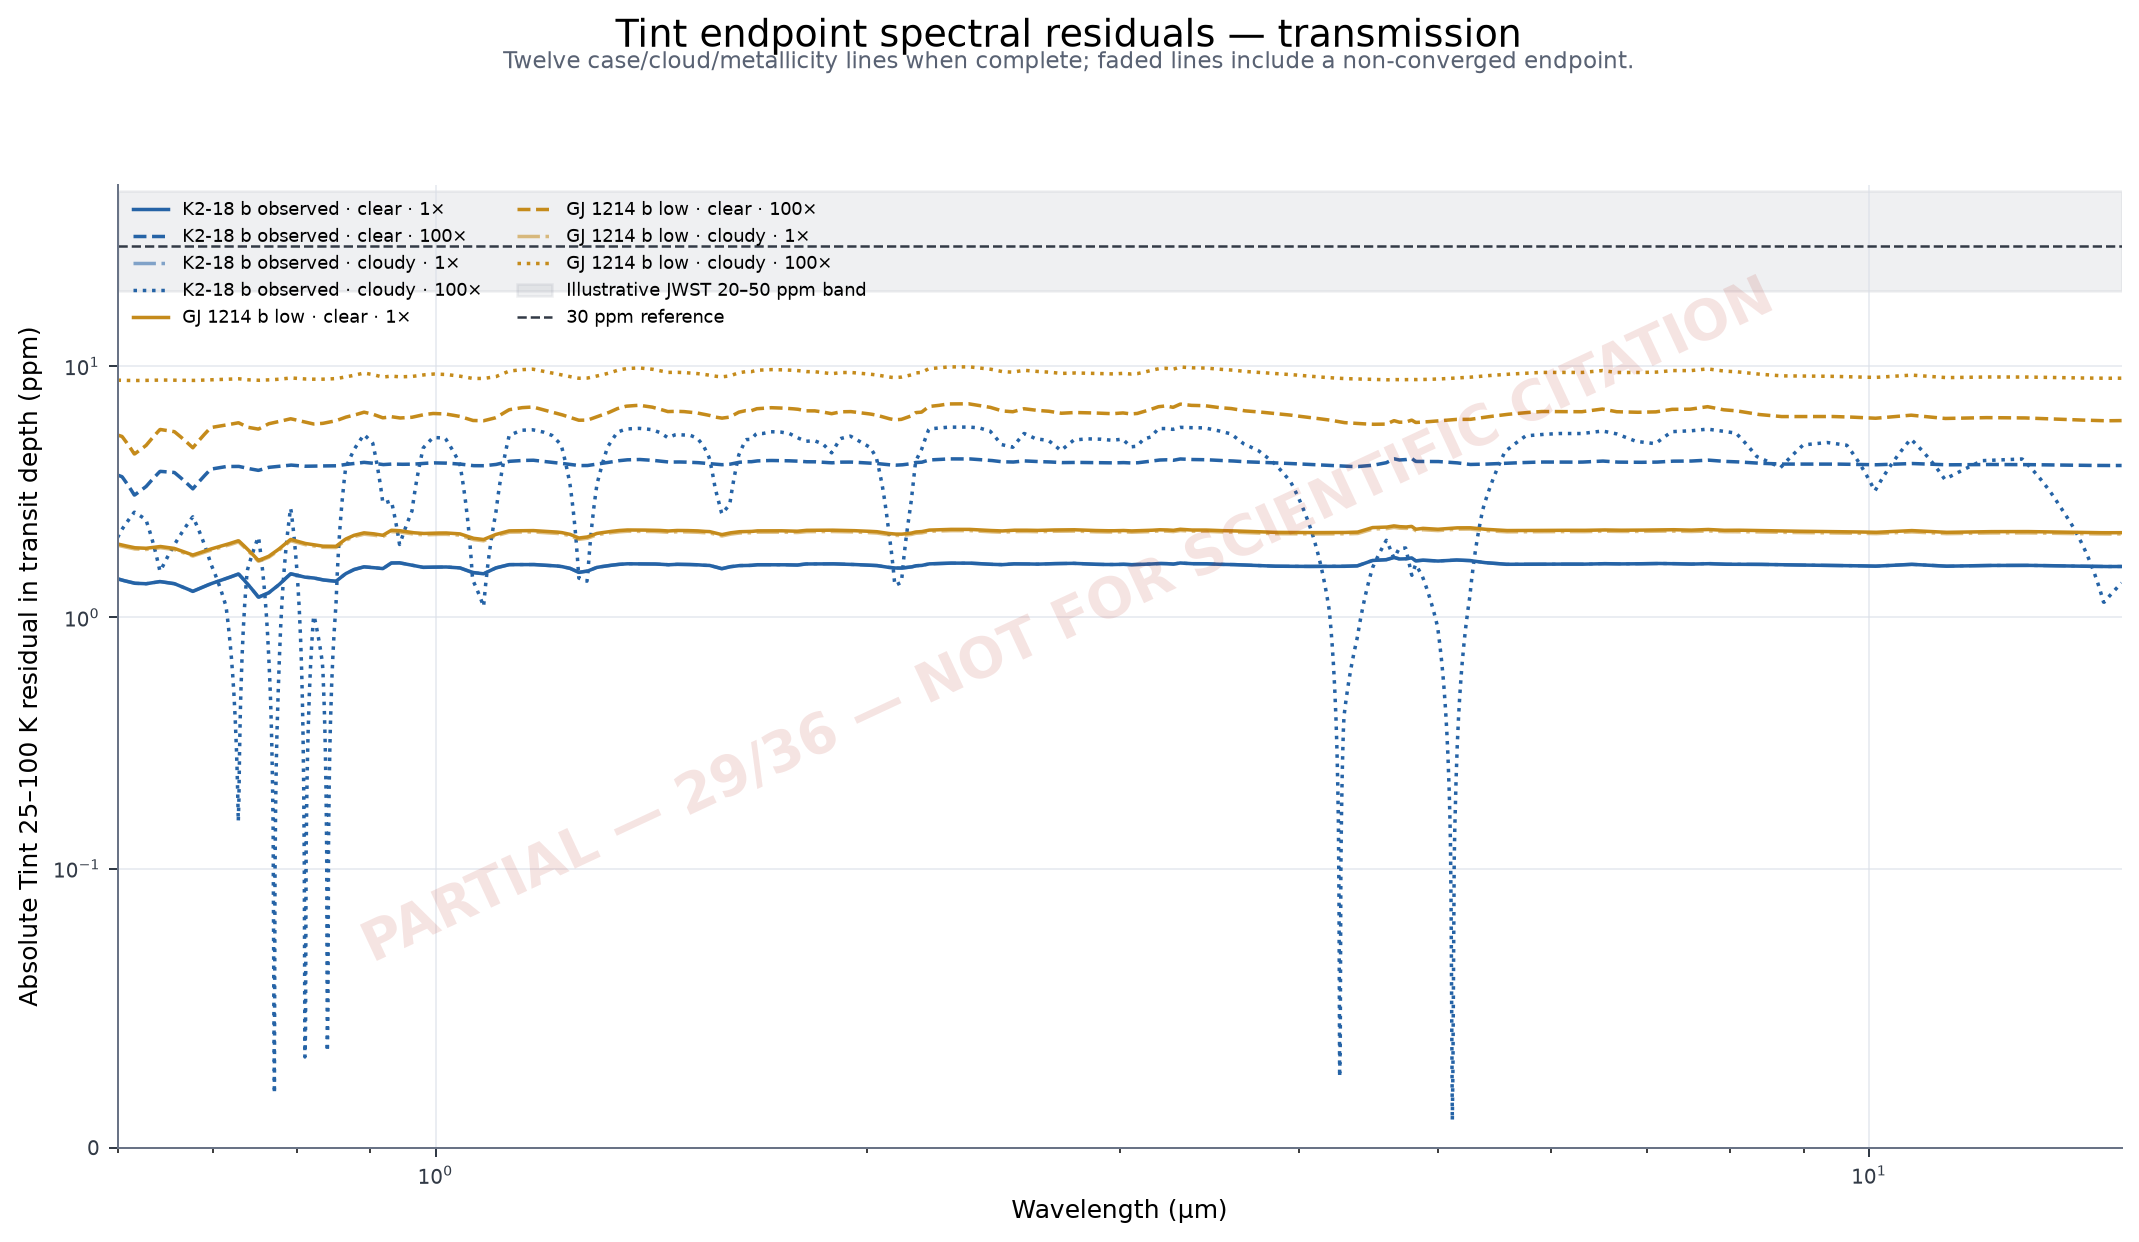

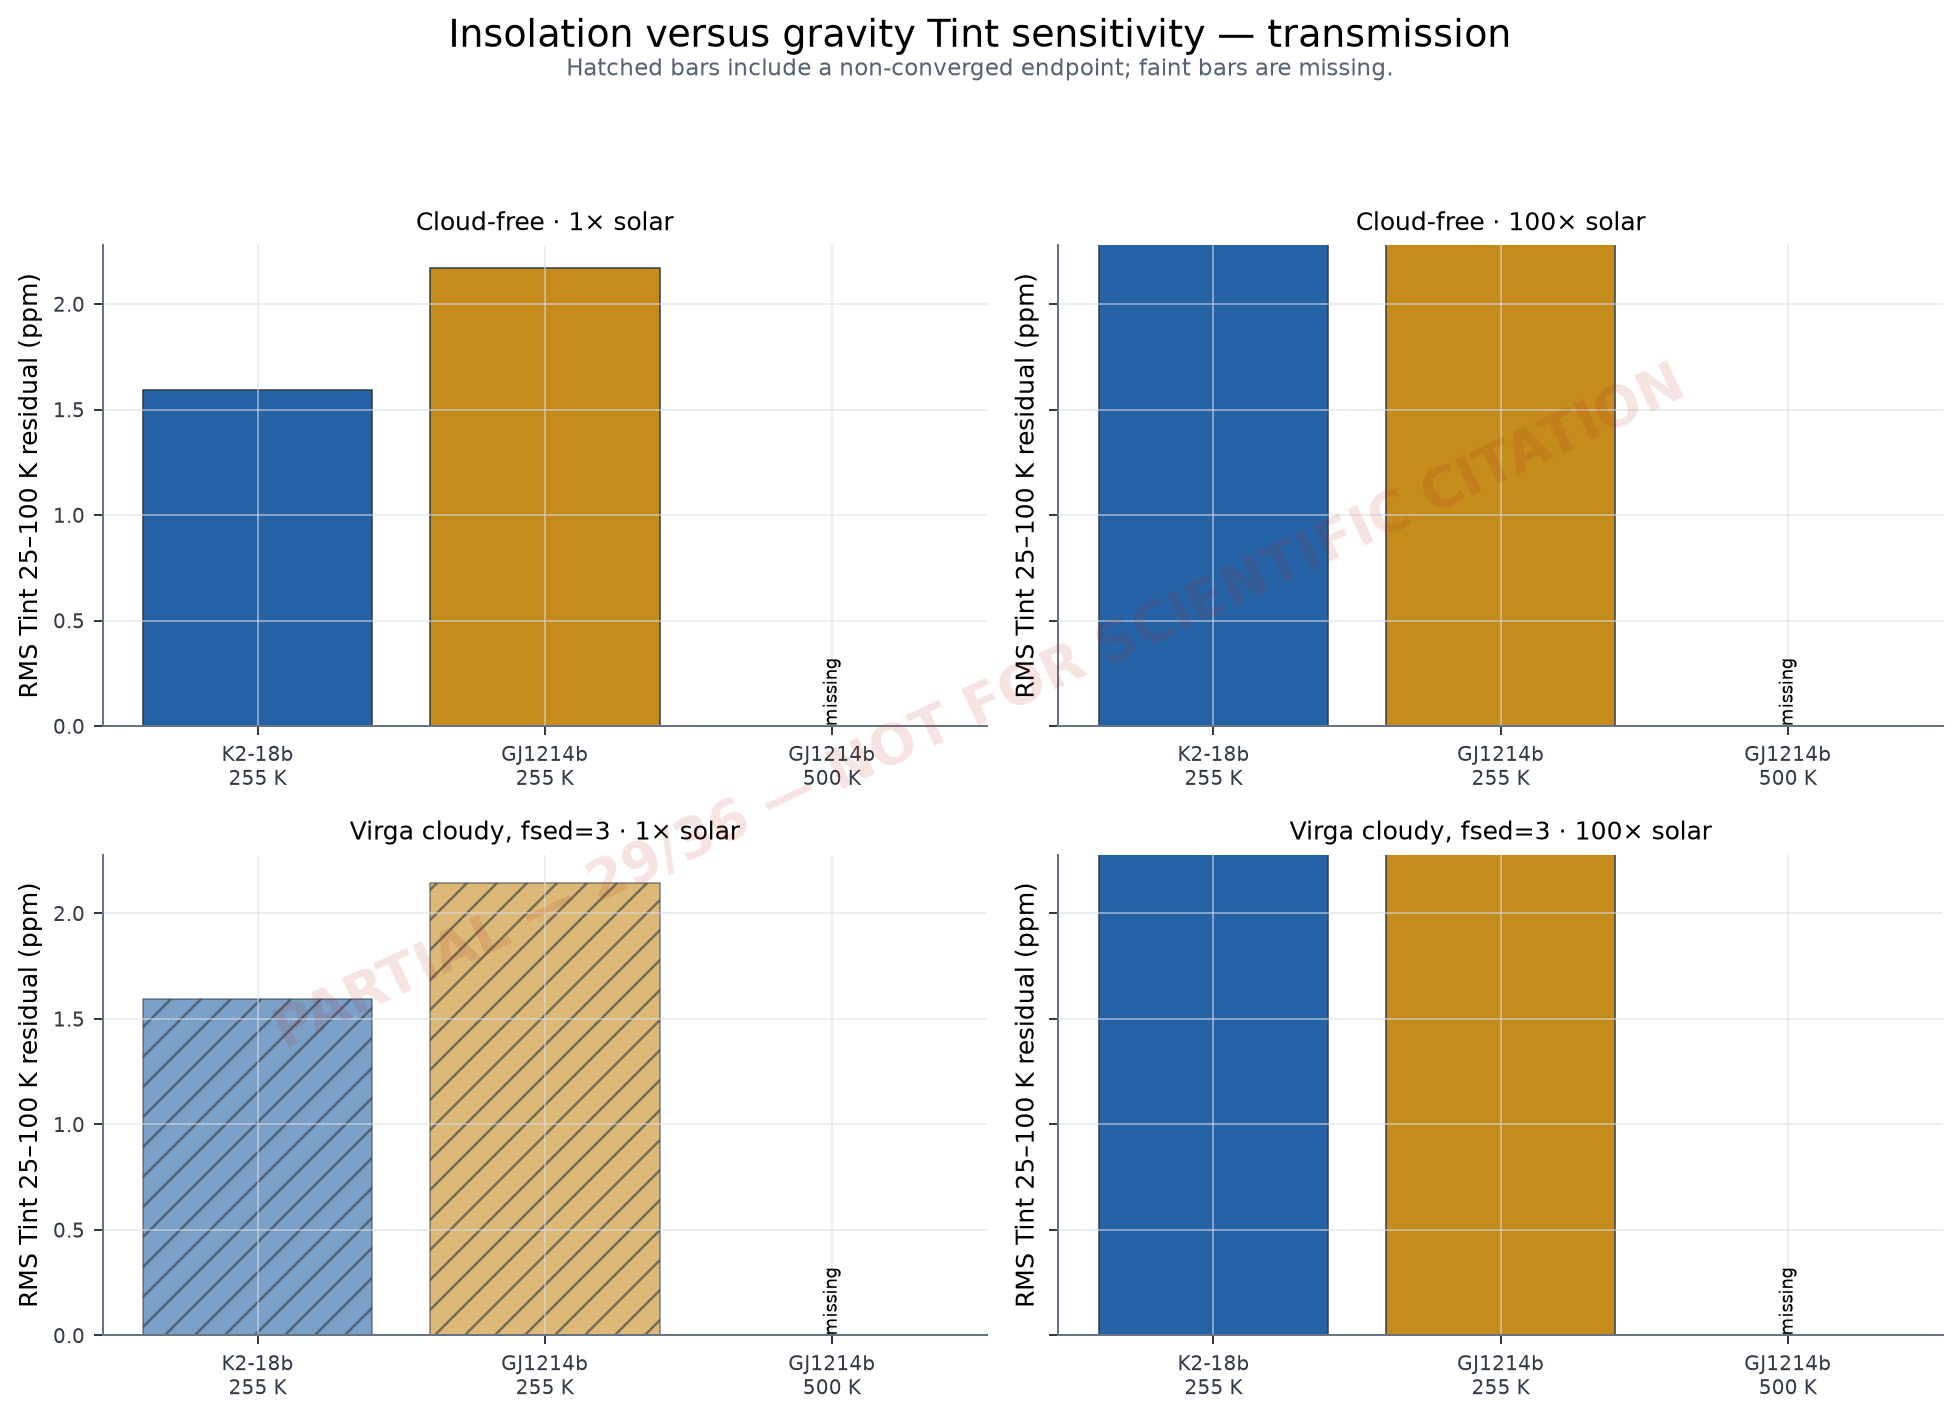

In [3]:
for name in [
    'pt_k2_18b_observed.png',
    'spectra_transmission_k2_18b_observed.png',
    'abundance_k2_18b_observed_cloud_free_100x.png',
    'residual_transmission.png',
    'case_metric_transmission.png',
]:
    display(Image(filename=str(package / 'figures' / name), width=950))

### 4. Evaluate chemistry sanity checks

In [4]:
display(h2o)
display(wogan)

,case_id,cloud_id,metallicity_xsolar,h2o_abs_change_dex_at_1mbar,advisory_over_0p1_dex,both_endpoints_converged
0,k2_18b_observed,cloud_free,1.0,0.006562,False,True
1,k2_18b_observed,cloud_free,100.0,0.035849,False,True
2,k2_18b_observed,fully_cloudy_virga,1.0,0.006571,False,False
3,k2_18b_observed,fully_cloudy_virga,100.0,0.046890,False,True
4,gj_1214b_low,cloud_free,1.0,0.006591,False,True
5,gj_1214b_low,cloud_free,100.0,0.039450,False,True
6,gj_1214b_low,fully_cloudy_virga,1.0,0.006585,False,False
7,gj_1214b_low,fully_cloudy_virga,100.0,0.043276,False,True


,case_id,cloud_id,metallicity_xsolar,CO_at_1mbar_tint25,CO_at_1mbar_tint50,CO_at_1mbar_tint100,CO_monotonic_increase_25_50_100,CO2_at_1mbar_tint25,CO2_at_1mbar_tint50,CO2_at_1mbar_tint100,CO2_monotonic_increase_25_50_100
0,k2_18b_observed,cloud_free,100.0,0.048992,0.049473,0.051265,True,0.001680,0.002197,0.002037,False
1,k2_18b_observed,fully_cloudy_virga,100.0,0.046795,0.044432,0.050117,False,0.001735,0.001856,0.001891,True


## Takeaways

- Use `FIGURE_INDEX.md` to navigate all 31 figure designs and 62 exports.
- Treat dashed curves and hatched bars as provisional.
- Thermal panels remain blank until corrected unit-consistent model outputs are present.
- Rebuild the final package only after its strict 36/36 convergence gate passes.